# OAG-CS Exploratory Data Analysis

Single-place data analysis for the report's Dataset section. Computes and visualizes everything the rubric asks for:

1. **Basic statistics**: node/edge counts per type
2. **Citation graph**: in/out degree distributions, density, isolated nodes
3. **Average clustering coefficient** (sampled, since the full graph is too big for exact computation)
4. **Author productivity**: heavy-tail papers-per-author distribution
5. **Temporal distribution**: papers per year, cumulative growth
6. **Feature analysis**: pairwise cosine-similarity histogram of title embeddings (the cluster-density issue)
7. **t-SNE of paper embeddings**: colored by L1 field-of-study
8. **FoS hierarchy**: per-level field counts and paper coverage
9. **Hard-negative pool sizes**: distribution of same-FoS-L2 candidates per paper
10. **Recommendation-task imbalance**: positives per author, history length, supervision per year
11. **Train/val/test split**: temporal cutoffs visualized
12. **Subgraph visualization**: a small 2-hop neighborhood drawn with networkx

All figures save to `figures/` for direct inclusion in the LaTeX report.

## Imports

In [2]:
import re
import time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from H2GB.datasets import OAGDataset

## Configuration

All paths and analysis parameters in one place. Figures are saved as PNGs at 150 DPI to `figures/` (relative to the notebook), suitable for direct `\includegraphics` in LaTeX.

In [3]:
OAG_ROOT = Path("./data/OAG")
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sampling sizes for expensive computations
COSINE_SAMPLE_SIZE = 2000          # for pairwise cosine similarity histogram
TSNE_SAMPLE_SIZE = 5000            # for t-SNE plot
CLUSTERING_SAMPLE_SIZE = 1000      # for approximate clustering coefficient
SUBGRAPH_HOPS = 2                  # for the example subgraph visualization

# Splits (consistent with v2 prep notebook)
VAL_YEAR = 2017
TEST_YEAR = 2018

# FoS level used for hard-negative sampling
FOS_LEVEL_HARDNEG = 2

# Plot style
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

print(f"Figure dir: {FIG_DIR.resolve()}")

Figure dir: /nfs/roberts/scratch/cpsc4830/cpsc4830_mae73/figures


## Section 1 — Load OAG-CS

Same loading recipe as the prep notebook. The H2GB OAGDataset returns a heterogeneous graph with paper/author/field/venue node types and per-type edges. Loading is slow ($\sim 1$ min) but only happens once per run.

In [4]:
OAGDataset.names['oag-cs'] = 'cs'
OAGDataset.urls['oag-cs'] = 'bypassed'

class CS_OAGDataset(OAGDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        self.name = 'oag-cs'
        super(OAGDataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
    def download(self):
        pass

t0 = time.time()
dataset = CS_OAGDataset(root=str(OAG_ROOT))
data = dataset[0]
print(f"Loaded OAG-CS in {time.time()-t0:.1f}s")
print(f"Node types: {data.node_types}")
print(f"Edge types: {data.edge_types}")

Loaded OAG-CS in 0.7s
Node types: ['paper', 'field', 'author', 'affiliation']
Edge types: [('paper', 'PP_cite', 'paper'), ('author', 'AP_write_last', 'paper'), ('author', 'AP_write_other', 'paper'), ('author', 'AP_write_first', 'paper'), ('field', 'FF_in', 'field'), ('paper', 'PF_in_L0', 'field'), ('paper', 'PF_in_L3', 'field'), ('paper', 'PF_in_L1', 'field'), ('paper', 'PF_in_L2', 'field'), ('paper', 'PF_in_L5', 'field'), ('paper', 'PF_in_L4', 'field'), ('author', 'in', 'affiliation')]


## Section 2 — Extract paper / citation / authorship / field data

Pull out the tensors we'll need throughout the EDA:

- Paper feature matrix $X \in \R^{N_p \times 768}$ (pretrained title embeddings)
- Paper years $\in \Z^{N_p}$
- Citation edge index $\in \Z^{2 \times E_c}$
- Author--paper merged edge index (deduplicated across the three role relations)
- All `PF_in_L*` field edges by level

In [5]:
# --- Paper data ---
X = data['paper'].x                          # (N_p, 768)
years = data['paper'].year                   # (N_p,)
num_papers = X.shape[0]
embed_dim = X.shape[1]

# --- Citation edges ---
cite_ei = data['paper', 'PP_cite', 'paper'].edge_index
cite_src, cite_dst = cite_ei[0], cite_ei[1]
num_cites = cite_src.shape[0]

# --- Authorship edges (merge first/last/other and dedup) ---
auth_a, auth_p = [], []
for rel in ['AP_write_first', 'AP_write_last', 'AP_write_other']:
    ei = data['author', rel, 'paper'].edge_index
    auth_a.append(ei[0]); auth_p.append(ei[1])
auth_a = torch.cat(auth_a); auth_p = torch.cat(auth_p)
pairs = torch.unique(torch.stack([auth_a, auth_p], dim=1), dim=0)
ap_a, ap_p = pairs[:, 0], pairs[:, 1]
num_authors = data['author'].num_nodes
num_ap = ap_a.shape[0]

# --- FoS edges by level ---
fos_edges = {}
for et in data.edge_types:
    src, rel, dst = et
    if src == 'paper' and dst == 'field' and 'PF_in_L' in rel:
        m = re.search(r'L(\d+)', rel)
        if m:
            fos_edges[int(m.group(1))] = data[et].edge_index
fos_levels = sorted(fos_edges.keys())

print(f"Papers:    {num_papers:,}")
print(f"Authors:   {num_authors:,}")
print(f"Citations: {num_cites:,}")
print(f"Auth-paper links (deduped): {num_ap:,}")
print(f"FoS levels available: {fos_levels}")
print(f"Year range: {years.min().item()} – {years.max().item()}")

Papers:    546,704
Authors:   511,122
Citations: 5,872,552
Auth-paper links (deduped): 1,552,196
FoS levels available: [0, 1, 2, 3, 4, 5]
Year range: 1922 – 2020


## Section 3 — Basic counts table

Saves a printed table that the report's Dataset section can quote verbatim.

In [6]:
print("=" * 50)
print("OAG-CS BASIC STATISTICS")
print("=" * 50)
print(f"{'Quantity':<35} {'Value':>14}")
print("-" * 50)
print(f"{'Papers (N_p)':<35} {num_papers:>14,}")
print(f"{'Authors (N_a)':<35} {num_authors:>14,}")
print(f"{'Citation edges (directed)':<35} {num_cites:>14,}")
print(f"{'Author-paper links (deduped)':<35} {num_ap:>14,}")
print(f"{'Paper feature dim':<35} {embed_dim:>14}")
print(f"{'FoS L0 fields':<35} {len(torch.unique(fos_edges[0][1])):>14,}")
print(f"{'FoS L2 fields (used for hard negs)':<35} {len(torch.unique(fos_edges[2][1])):>14,}")
print(f"{'Year min':<35} {years.min().item():>14}")
print(f"{'Year max':<35} {years.max().item():>14}")

OAG-CS BASIC STATISTICS
Quantity                                     Value
--------------------------------------------------
Papers (N_p)                               546,704
Authors (N_a)                              511,122
Citation edges (directed)                5,872,552
Author-paper links (deduped)             1,552,196
Paper feature dim                              768
FoS L0 fields                                   13
FoS L2 fields (used for hard negs)          17,750
Year min                                      1922
Year max                                      2020


## Section 4 — Citation graph degree distributions

Compute outgoing and incoming citation counts per paper. Plot both as log-scale histograms — citation graphs are heavy-tailed: most papers have few citations, a few have thousands.

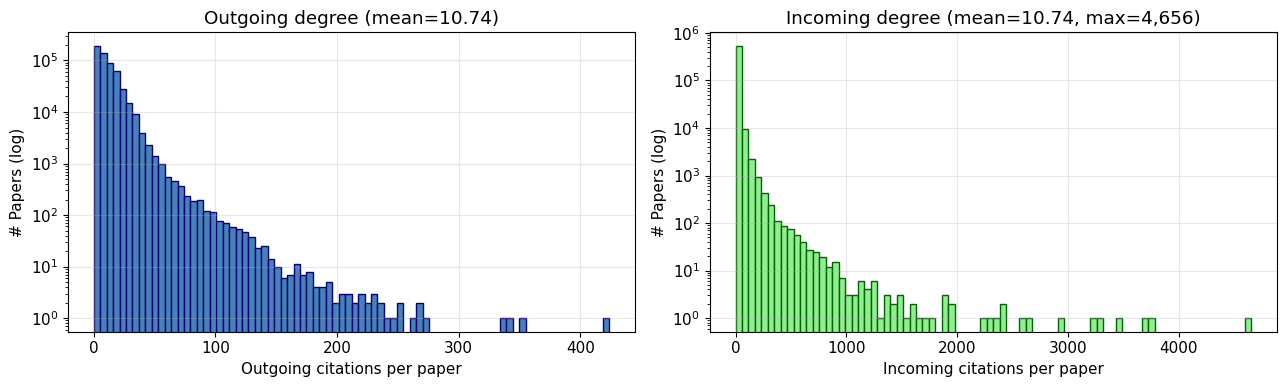


Degree summary:
  Outgoing: mean=10.74, median=8, max=424
  Incoming: mean=10.74, median=5, max=4,656
  Papers with 0 outgoing citations: 33,951 (6.2%)
  Papers with 0 incoming citations: 61,779 (11.3%)


In [7]:
out_deg = torch.bincount(cite_src, minlength=num_papers)  # outgoing citations
in_deg = torch.bincount(cite_dst, minlength=num_papers)   # incoming (cited-by)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(out_deg.numpy(), bins=80, color='steelblue', edgecolor='navy', log=True)
axes[0].set_xlabel('Outgoing citations per paper')
axes[0].set_ylabel('# Papers (log)')
axes[0].set_title(f'Outgoing degree (mean={out_deg.float().mean():.2f})')
axes[0].set_yscale('log')
axes[1].hist(in_deg.numpy(), bins=80, color='lightgreen', edgecolor='darkgreen', log=True)
axes[1].set_xlabel('Incoming citations per paper')
axes[1].set_ylabel('# Papers (log)')
axes[1].set_title(f'Incoming degree (mean={in_deg.float().mean():.2f}, max={in_deg.max().item():,})')
axes[1].set_yscale('log')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_citation_degree.png')
plt.show()

print(f"\nDegree summary:")
print(f"  Outgoing: mean={out_deg.float().mean():.2f}, median={out_deg.float().median():.0f}, max={out_deg.max().item():,}")
print(f"  Incoming: mean={in_deg.float().mean():.2f}, median={in_deg.float().median():.0f}, max={in_deg.max().item():,}")
print(f"  Papers with 0 outgoing citations: {(out_deg == 0).sum().item():,} ({100*(out_deg == 0).float().mean():.1f}%)")
print(f"  Papers with 0 incoming citations: {(in_deg == 0).sum().item():,} ({100*(in_deg == 0).float().mean():.1f}%)")

## Section 5 — Graph density

$$\text{density}(G) = \frac{|E|}{|V|(|V|-1)}.$$
Citation graphs are extremely sparse — values around $10^{-5}$ are typical for academic citation networks.

In [8]:
density = num_cites / (num_papers * (num_papers - 1))
print(f"Citation graph density: {density:.2e}")
print(f"  (i.e. ~{density*1e6:.1f} edges per million possible pairs)")
print(f"Average citations per paper: {num_cites / num_papers:.2f}")
print(f"Isolated papers (no citations in or out): {((out_deg == 0) & (in_deg == 0)).sum().item():,}")

Citation graph density: 1.96e-05
  (i.e. ~19.6 edges per million possible pairs)
Average citations per paper: 10.74
Isolated papers (no citations in or out): 6,656


## Section 6 — Average clustering coefficient (sampled, real neighbors)

The clustering coefficient at a node is the fraction of pairs of its neighbors that are also connected. Exact computation on 546K nodes is infeasible.

**Important**: a naive random-sample-then-induce-subgraph approach gives ~0 (most random pairs aren't connected). We must compute clustering *per sampled node using the node's real neighbors in the full graph*, not just the induced subgraph.

We treat the citation graph as **undirected** for clustering: build a full adjacency dict, then for each sampled node compute its local clustering coefficient using its real neighbor set. Average across the sample.

In [9]:
# Build full undirected adjacency (set per node) once. Memory ~ 2 * num_cites * 8 bytes ~ 100 MB.
print("Building full undirected adjacency for clustering computation...")
t0 = time.time()
adj = defaultdict(set)
for s, d in zip(cite_src.tolist(), cite_dst.tolist()):
    if s != d:
        adj[s].add(d)
        adj[d].add(s)
print(f"  built in {time.time()-t0:.1f}s, {len(adj):,} nodes have at least one neighbor")

def local_clustering(node, adj):
    """Local clustering coefficient of a single node using its real neighbors."""
    nbrs = adj[node]
    n = len(nbrs)
    if n < 2:
        return 0.0
    # Count edges among neighbors of `node`
    triangles = 0
    nbr_list = list(nbrs)
    for i, u in enumerate(nbr_list):
        # Intersect adj[u] with nbrs that come after u in the list (avoid double-counting)
        adj_u = adj[u]
        for v in nbr_list[i+1:]:
            if v in adj_u:
                triangles += 1
    return 2 * triangles / (n * (n - 1))

rng = np.random.default_rng(42)
sample = rng.choice(num_papers, size=min(CLUSTERING_SAMPLE_SIZE, num_papers), replace=False)
t0 = time.time()
local_ccs = [local_clustering(int(n), adj) for n in sample]
elapsed = time.time() - t0

avg_clust = float(np.mean(local_ccs))
nonzero_frac = float(np.mean(np.array(local_ccs) > 0))

print(f"\nAverage clustering coefficient (sample of {len(sample):,} nodes, real neighbors):")
print(f"  Mean local clustering: {avg_clust:.4f}")
print(f"  Median local clustering: {np.median(local_ccs):.4f}")
print(f"  Fraction of sampled nodes with nonzero clustering: {nonzero_frac:.4f}")
print(f"  Computed in {elapsed:.1f}s")

# Transitivity (global clustering): 3 * triangles / connected triples
# Approximate via the same sample's per-node clustering weighted by degree(degree-1)/2
# (this is the unbiased estimator)
weights = []
for n in sample:
    k = len(adj[int(n)])
    weights.append(k * (k - 1) / 2 if k >= 2 else 0)
weights = np.array(weights)
local_ccs_arr = np.array(local_ccs)
if weights.sum() > 0:
    transitivity = float((local_ccs_arr * weights).sum() / weights.sum())
else:
    transitivity = 0.0
print(f"  Transitivity estimate (degree-weighted): {transitivity:.4f}")

Building full undirected adjacency for clustering computation...
  built in 11.2s, 540,048 nodes have at least one neighbor

Average clustering coefficient (sample of 1,000 nodes, real neighbors):
  Mean local clustering: 0.1527
  Median local clustering: 0.1321
  Fraction of sampled nodes with nonzero clustering: 0.9020
  Computed in 0.1s
  Transitivity estimate (degree-weighted): 0.0559


## Section 7 — Author productivity (heavy-tail)

Papers per author distribution. The heavy tail with most authors having very few papers is a well-known property of co-authorship networks; in OAG-CS, $\sim 62\%$ of authors have only one paper. This single fact has the largest impact on which authors are usable as supervision (we need history).

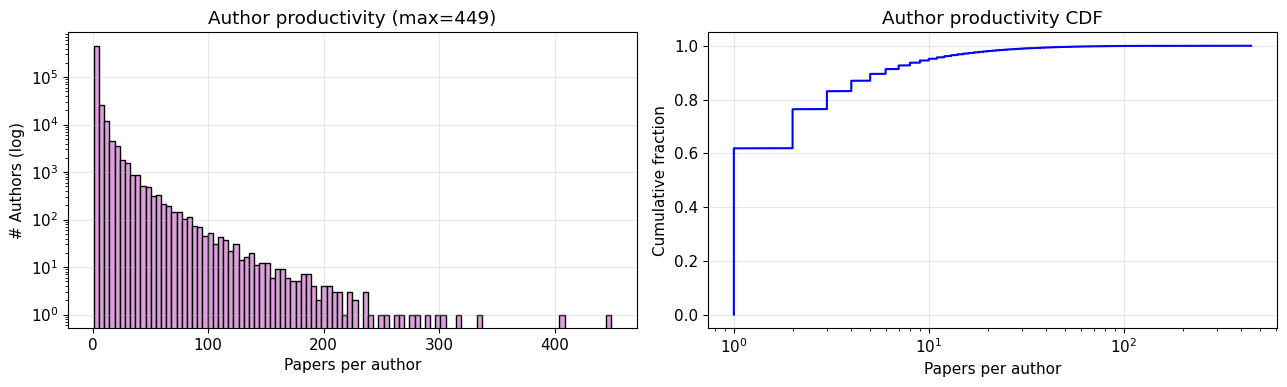


Author productivity:
  0 papers:  0 (0.0%) [no link to paper data]
  1 paper:   316,147 (61.9%) [no usable history]
  >=2 papers: 194,975 (38.1%) [eligible for supervision]
  Mean: 3.04
  Median: 1


In [10]:
papers_per_author = torch.bincount(ap_a, minlength=num_authors)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(papers_per_author.numpy(), bins=100, color='plum', edgecolor='black', log=True)
axes[0].set_xlabel('Papers per author')
axes[0].set_ylabel('# Authors (log)')
axes[0].set_title(f'Author productivity (max={papers_per_author.max().item()})')
axes[0].set_yscale('log')

# CDF
vals = sorted(papers_per_author.tolist())
ecdf = np.arange(len(vals)) / len(vals)
axes[1].plot(vals, ecdf, 'b-')
axes[1].set_xlabel('Papers per author')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Author productivity CDF')
axes[1].set_xscale('log')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_author_productivity.png')
plt.show()

n_zero = (papers_per_author == 0).sum().item()
n_one = (papers_per_author == 1).sum().item()
n_multi = (papers_per_author >= 2).sum().item()
print(f"\nAuthor productivity:")
print(f"  0 papers:  {n_zero:,} ({100*n_zero/num_authors:.1f}%) [no link to paper data]")
print(f"  1 paper:   {n_one:,} ({100*n_one/num_authors:.1f}%) [no usable history]")
print(f"  >=2 papers: {n_multi:,} ({100*n_multi/num_authors:.1f}%) [eligible for supervision]")
print(f"  Mean: {papers_per_author.float().mean():.2f}")
print(f"  Median: {papers_per_author.float().median():.0f}")

## Section 8 — Temporal distribution

Papers per year, and cumulative paper count. The split lines show train/val/test cutoffs. The shape (exponential growth, knee around 2000) is typical of digitized academic corpora.

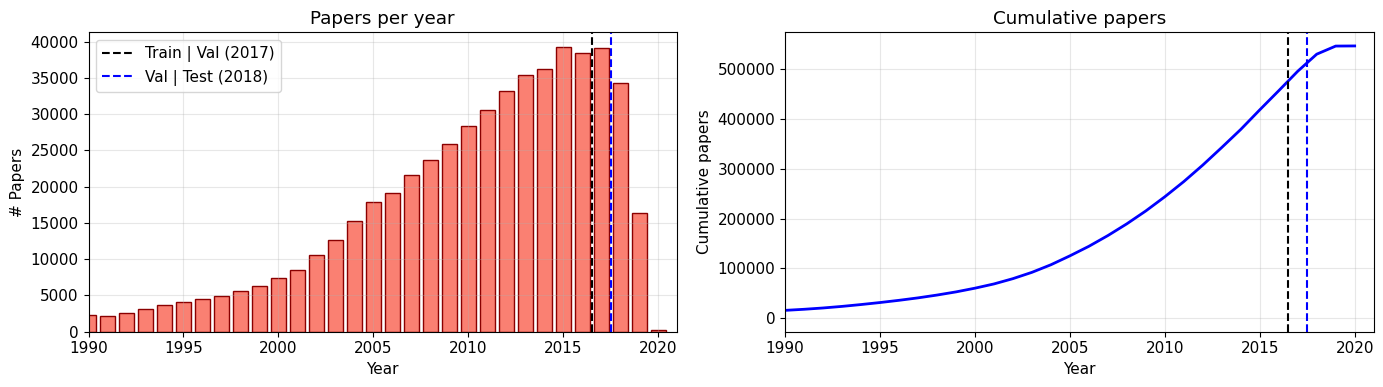


Split sizes by year:
  Train (year < 2017): 456,776 papers (83.6%)
  Val (year = 2017):   39,072 papers (7.1%)
  Test (year >= 2018): 50,856 papers (9.3%)


In [11]:
years_np = years.numpy()
year_vals, year_counts = np.unique(years_np, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(year_vals, year_counts, color='salmon', edgecolor='darkred')
axes[0].axvline(VAL_YEAR - 0.5, color='black', linestyle='--', label=f'Train | Val ({VAL_YEAR})')
axes[0].axvline(TEST_YEAR - 0.5, color='blue', linestyle='--', label=f'Val | Test ({TEST_YEAR})')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('# Papers'); axes[0].set_title('Papers per year')
axes[0].set_xlim(1990, 2021)
axes[0].legend()
axes[1].plot(year_vals, np.cumsum(year_counts), 'b-', linewidth=2)
axes[1].axvline(VAL_YEAR - 0.5, color='black', linestyle='--')
axes[1].axvline(TEST_YEAR - 0.5, color='blue', linestyle='--')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Cumulative papers')
axes[1].set_title('Cumulative papers')
axes[1].set_xlim(1990, 2021)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_papers_per_year.png')
plt.show()

train_papers = (years < VAL_YEAR).sum().item()
val_papers = (years == VAL_YEAR).sum().item()
test_papers = (years >= TEST_YEAR).sum().item()
print(f"\nSplit sizes by year:")
print(f"  Train (year < {VAL_YEAR}): {train_papers:,} papers ({100*train_papers/num_papers:.1f}%)")
print(f"  Val (year = {VAL_YEAR}):   {val_papers:,} papers ({100*val_papers/num_papers:.1f}%)")
print(f"  Test (year >= {TEST_YEAR}): {test_papers:,} papers ({100*test_papers/num_papers:.1f}%)")

## Section 9 — Feature analysis (pairwise cosine similarity)

Sample $N$ random papers, compute the upper triangle of the cosine-similarity matrix, plot the histogram. The reported mean of $\sim 0.99$ for OAG-CS title embeddings is the central data-quality issue: every two papers' titles are very similar by default, which makes ranking against random distractors easier than it should be (and forces hard-negative sampling to test discrimination).

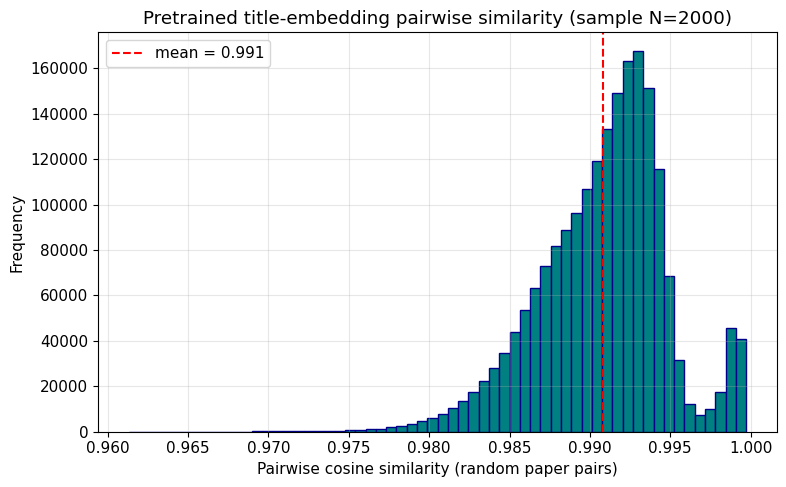


Pairwise cosine similarity (sample of 2000 papers, 1,999,000 pairs):
  Mean:   0.9908
  Median: 0.9913
  Min:    0.9613
  Max:    0.9997
  10th-percentile: 0.9856
  90th-percentile: 0.9949


In [12]:
rng = np.random.default_rng(0)
samp_idx = rng.choice(num_papers, size=COSINE_SAMPLE_SIZE, replace=False)
Xs = X[samp_idx]
Xs_norm = Xs / Xs.norm(dim=-1, keepdim=True).clamp(min=1e-8)
sim = Xs_norm @ Xs_norm.t()                                # (S, S)
iu = torch.triu_indices(sim.shape[0], sim.shape[0], offset=1)
vals = sim[iu[0], iu[1]].numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=60, color='teal', edgecolor='darkblue')
ax.axvline(vals.mean(), color='red', linestyle='--', label=f'mean = {vals.mean():.3f}')
ax.set_xlabel('Pairwise cosine similarity (random paper pairs)')
ax.set_ylabel('Frequency')
ax.set_title(f'Pretrained title-embedding pairwise similarity (sample N={COSINE_SAMPLE_SIZE})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_pairwise_cosine.png')
plt.show()

print(f"\nPairwise cosine similarity (sample of {COSINE_SAMPLE_SIZE} papers, {len(vals):,} pairs):")
print(f"  Mean:   {vals.mean():.4f}")
print(f"  Median: {np.median(vals):.4f}")
print(f"  Min:    {vals.min():.4f}")
print(f"  Max:    {vals.max():.4f}")
print(f"  10th-percentile: {np.percentile(vals, 10):.4f}")
print(f"  90th-percentile: {np.percentile(vals, 90):.4f}")

## Section 10 — t-SNE of paper embeddings, colored by L1 field

Project a sample of paper embeddings to 2D via t-SNE. Color each point by its **first L1 field-of-study** (e.g. "Machine Learning", "Computer Vision"). If the model can recover topical structure from these features alone, you should see clear clusters.

Sample size $\sim 5000$ keeps the t-SNE under 1 minute. We restrict to the top 12 most-frequent L1 fields for legibility.

Running t-SNE on 5000 papers (768-dim -> 2-dim)...
t-SNE done in 50.6s


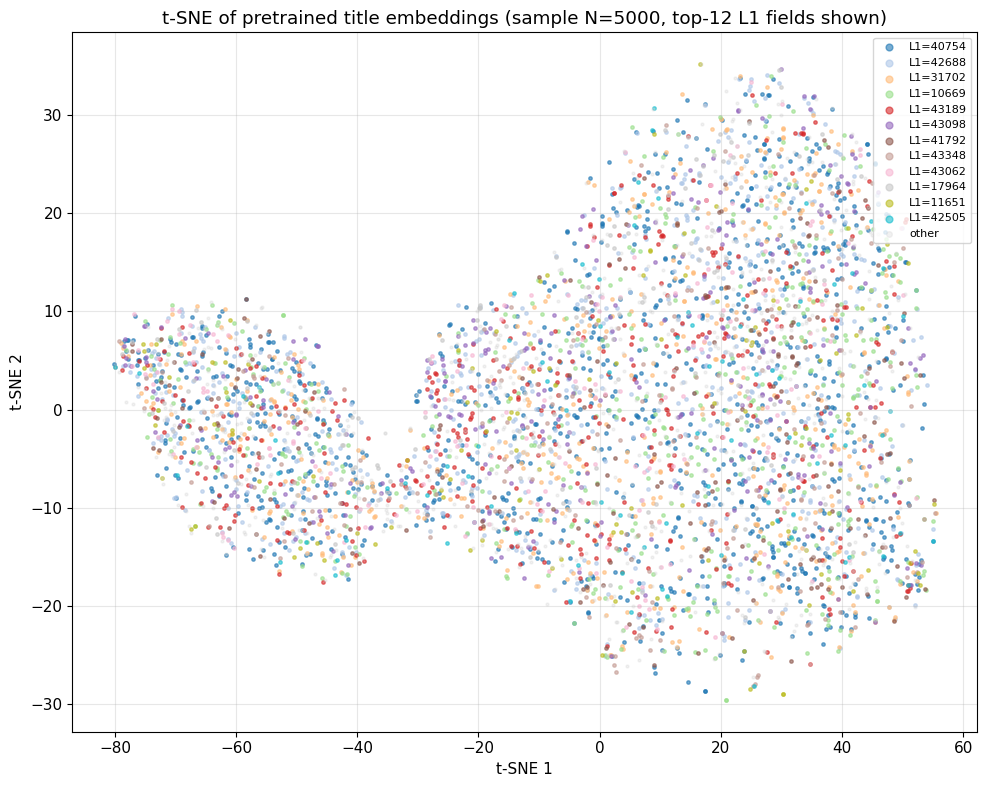

In [13]:
from sklearn.manifold import TSNE

# Build paper -> first-L1-field map
ei_l1 = fos_edges[1]
paper_to_l1 = {}
for p, f in zip(ei_l1[0].tolist(), ei_l1[1].tolist()):
    if p not in paper_to_l1:
        paper_to_l1[p] = f

# Sample papers that have an L1 tag
tagged = np.array([p for p in range(num_papers) if p in paper_to_l1])
rng = np.random.default_rng(7)
samp_idx = rng.choice(tagged, size=min(TSNE_SAMPLE_SIZE, len(tagged)), replace=False)
samp_X = X[samp_idx].numpy()
samp_field = np.array([paper_to_l1[p] for p in samp_idx])

# Top-K most frequent L1 fields
top_k = 12
field_counts = Counter(samp_field.tolist())
top_fields = [f for f, _ in field_counts.most_common(top_k)]
field_to_color = {f: cm.tab20(i / top_k) for i, f in enumerate(top_fields)}

print(f"Running t-SNE on {len(samp_X)} papers ({embed_dim}-dim -> 2-dim)...")
t0 = time.time()
# sklearn renamed n_iter -> max_iter in 1.5; default (1000) is fine, just omit
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
Z = tsne.fit_transform(samp_X)
print(f"t-SNE done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(10, 8))
for f in top_fields:
    mask = samp_field == f
    ax.scatter(Z[mask, 0], Z[mask, 1], c=[field_to_color[f]], s=6, alpha=0.6, label=f'L1={f}')
mask_other = ~np.isin(samp_field, top_fields)
ax.scatter(Z[mask_other, 0], Z[mask_other, 1], c='lightgray', s=4, alpha=0.3, label='other')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE of pretrained title embeddings (sample N={len(samp_X)}, top-{top_k} L1 fields shown)')
ax.legend(loc='upper right', fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_tsne_papers.png')
plt.show()

## Section 11 — FoS hierarchy statistics

For each available L0--L5 level: number of distinct fields, paper coverage, mean papers per field. This is the same diagnostic the prep notebook uses to choose `FOS_LEVEL=2`. Reproduced here for the report.

 L |   n_fields |  p_cov |    mean_p/f |   med_p/f |   max_p/f |  mean_f/p
--------------------------------------------------------------------------
 0 |         13 | 100.0% |    42,063.9 |      11.0 |   546,704 |      1.00
 1 |        275 | 100.0% |     4,372.7 |      47.0 |   172,108 |      2.20
 2 |     17,750 |  96.9% |       132.2 |       6.0 |    27,634 |      4.43
 3 |     14,615 |  78.6% |        59.5 |       4.0 |    10,518 |      2.02
 4 |      7,245 |  37.2% |        42.1 |       4.0 |     2,740 |      1.50
 5 |      5,877 |  21.0% |        34.6 |       5.0 |     1,829 |      1.77


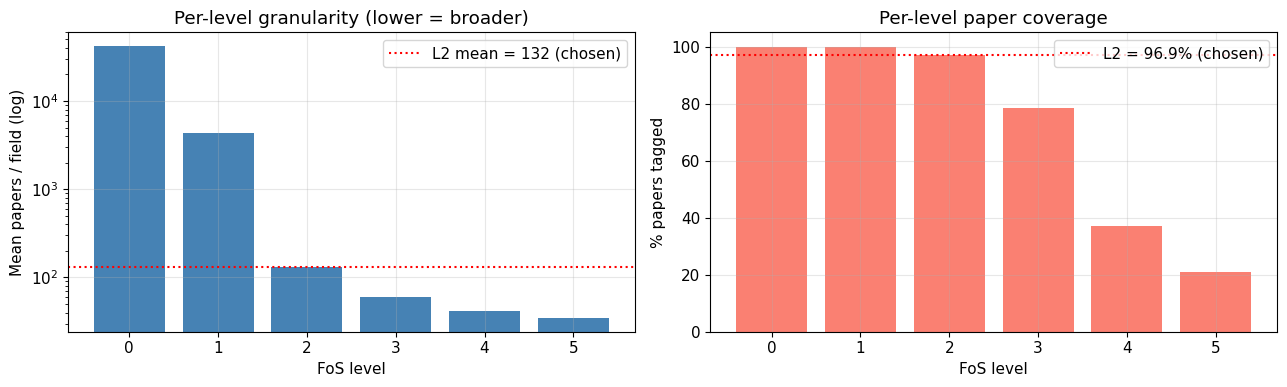

In [14]:
level_stats = []
for lvl in fos_levels:
    ei = fos_edges[lvl]
    paper_ids, field_ids = ei[0], ei[1]
    _, ppf = torch.unique(field_ids, return_counts=True)
    _, fpp = torch.unique(paper_ids, return_counts=True)
    coverage = fpp.numel() / num_papers
    level_stats.append({
        'level': lvl,
        'n_fields': ppf.numel(),
        'paper_coverage': coverage,
        'mean_papers_per_field': ppf.float().mean().item(),
        'median_papers_per_field': ppf.float().median().item(),
        'max_papers_per_field': ppf.max().item(),
        'mean_fields_per_paper': fpp.float().mean().item(),
    })

header = f"{'L':>2} | {'n_fields':>10} | {'p_cov':>6} | {'mean_p/f':>11} | {'med_p/f':>9} | {'max_p/f':>9} | {'mean_f/p':>9}"
print(header); print('-' * len(header))
for s in level_stats:
    print(f"{s['level']:>2} | {s['n_fields']:>10,} | {s['paper_coverage']*100:>5.1f}% | "
          f"{s['mean_papers_per_field']:>11,.1f} | {s['median_papers_per_field']:>9,.1f} | "
          f"{s['max_papers_per_field']:>9,} | {s['mean_fields_per_paper']:>9.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lv = [s['level'] for s in level_stats]
axes[0].bar(lv, [s['mean_papers_per_field'] for s in level_stats], color='steelblue')
axes[0].set_yscale('log')
axes[0].set_xlabel('FoS level'); axes[0].set_ylabel('Mean papers / field (log)')
axes[0].set_title('Per-level granularity (lower = broader)')
axes[0].axhline(132, color='red', linestyle=':', label='L2 mean = 132 (chosen)')
axes[0].legend()
axes[1].bar(lv, [s['paper_coverage']*100 for s in level_stats], color='salmon')
axes[1].set_xlabel('FoS level'); axes[1].set_ylabel('% papers tagged')
axes[1].set_title('Per-level paper coverage')
axes[1].set_ylim(0, 105)
axes[1].axhline(96.9, color='red', linestyle=':', label='L2 = 96.9% (chosen)')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_fos_levels.png')
plt.show()

## Section 12 — Hard-negative pool sizes at FoS L2

For each paper, how many other papers share at least one L2 field with it? This is the size of its same-field candidate pool, which directly upper-bounds how many hard negatives we can sample for it during training and evaluation. The distribution should be heavy-tailed (mainstream-field papers have huge pools; rare-field papers have tiny ones).

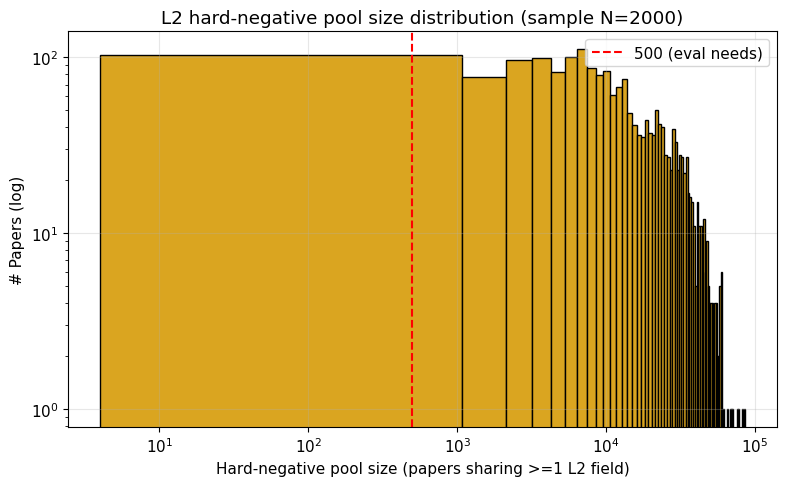


Hard-neg pool size (sample of 2000 papers):
  Mean:    15,992
  Median:  11,932
  Min:     4
  Max:     85,176
  Papers with pool < 500 (eval would top up with random): 50 (2.5%)


In [15]:
# Build paper -> set of L2 fields, and field -> set of papers, for L2.
ei_l2 = fos_edges[FOS_LEVEL_HARDNEG]
paper_to_l2 = defaultdict(set)
field_to_papers = defaultdict(set)
for p, f in zip(ei_l2[0].tolist(), ei_l2[1].tolist()):
    paper_to_l2[p].add(f)
    field_to_papers[f].add(p)

# For a sample of papers, compute the size of their hard-negative pool
# (union of papers sharing >=1 L2 field, minus the paper itself).
rng = np.random.default_rng(0)
tagged = list(paper_to_l2.keys())
samp = rng.choice(len(tagged), size=min(2000, len(tagged)), replace=False)
pool_sizes = []
for i in samp:
    p = tagged[i]
    union = set()
    for f in paper_to_l2[p]:
        union |= field_to_papers[f]
    union.discard(p)
    pool_sizes.append(len(union))
pool_sizes = np.array(pool_sizes)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pool_sizes, bins=80, color='goldenrod', edgecolor='black')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.axvline(500, color='red', linestyle='--', label='500 (eval needs)')
ax.set_xlabel('Hard-negative pool size (papers sharing >=1 L2 field)')
ax.set_ylabel('# Papers (log)')
ax.set_title(f'L2 hard-negative pool size distribution (sample N={len(samp)})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_hardneg_pool.png')
plt.show()

print(f"\nHard-neg pool size (sample of {len(samp)} papers):")
print(f"  Mean:    {pool_sizes.mean():,.0f}")
print(f"  Median:  {np.median(pool_sizes):,.0f}")
print(f"  Min:     {pool_sizes.min():,}")
print(f"  Max:     {pool_sizes.max():,}")
print(f"  Papers with pool < 500 (eval would top up with random): "
      f"{(pool_sizes < 500).sum():,} ({100*(pool_sizes < 500).mean():.1f}%)")

## Section 13 — Recommendation-task imbalance

Three task-specific distributions:
1. **Positives per supervision example** — how many papers each supervision-year paper cites that are still in the candidate pool. Median is small (most papers cite a handful).
2. **History length** — how many pre-year papers each eligible author has. Right-skewed.
3. **Class imbalance per example** — with $5 \times |\text{positives}|$ negatives, positive ratio is $1/6 \approx 16.7\%$ at training time.

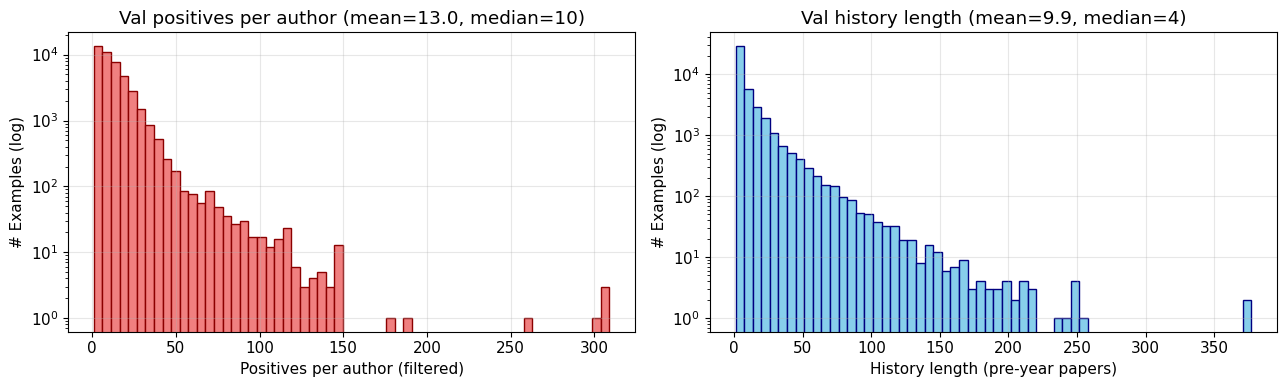


Val supervision (NEG_SAMPLES=5 per positive at training time):
  Mean positives per author:  13.04
  Mean history length:        9.92
  Effective train pos:neg:    1:5 (positives:negatives per example)
  Authors with single-paper history: 10,043 (23.1%)


In [16]:
# Use saved val.pt (already has supervision examples with positives + history)
PROCESSED_DIR = Path('./data/processed_v2')
if (PROCESSED_DIR / 'val.pt').exists():
    val_data = torch.load(PROCESSED_DIR / 'val.pt', weights_only=False)
    pos_per_ex = np.array([len(ex['positive_locals']) for ex in val_data['supervision']])
    hist_per_ex = np.array([len(ex['history_locals']) for ex in val_data['supervision']])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(pos_per_ex, bins=60, color='lightcoral', edgecolor='darkred', log=True)
    axes[0].set_xlabel('Positives per author (filtered)')
    axes[0].set_ylabel('# Examples (log)')
    axes[0].set_title(f'Val positives per author (mean={pos_per_ex.mean():.1f}, median={np.median(pos_per_ex):.0f})')
    axes[1].hist(hist_per_ex, bins=60, color='skyblue', edgecolor='navy', log=True)
    axes[1].set_xlabel('History length (pre-year papers)')
    axes[1].set_ylabel('# Examples (log)')
    axes[1].set_title(f'Val history length (mean={hist_per_ex.mean():.1f}, median={np.median(hist_per_ex):.0f})')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eda_task_imbalance.png')
    plt.show()

    print(f"\nVal supervision (NEG_SAMPLES=5 per positive at training time):")
    print(f"  Mean positives per author:  {pos_per_ex.mean():.2f}")
    print(f"  Mean history length:        {hist_per_ex.mean():.2f}")
    print(f"  Effective train pos:neg:    1:5 (positives:negatives per example)")
    print(f"  Authors with single-paper history: {(hist_per_ex == 1).sum():,} "
          f"({100*(hist_per_ex == 1).mean():.1f}%)")
else:
    print(f"Skipped — {PROCESSED_DIR / 'val.pt'} not found.")
    print("Run v2_02b_prepare_oag_cs.ipynb first to enable this section.")

## Section 14 — Per-year supervision counts

How many supervision examples does each training year contribute? Year 2005 should have very few; year 2016 many. This affects how to weight years during training (we don't currently do this, but it's worth noting in the report).

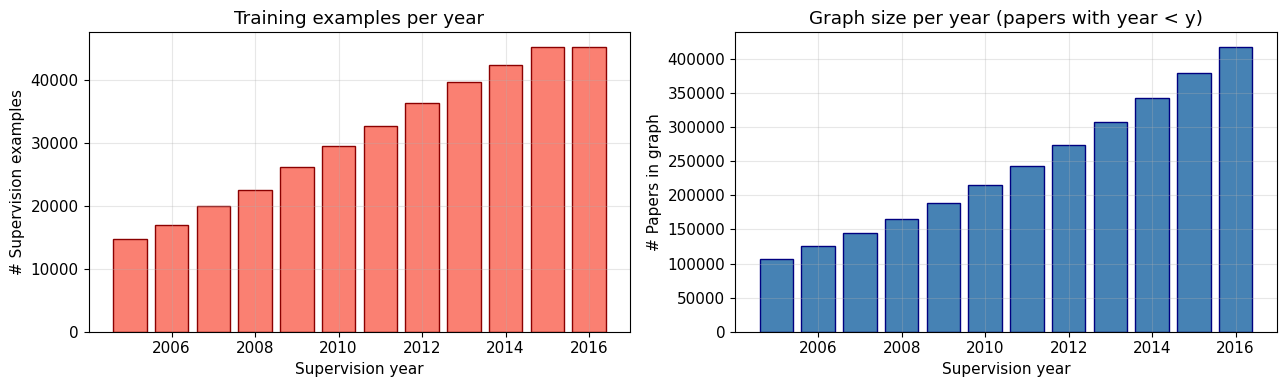


Total training supervision examples: 372,027


In [17]:
if (PROCESSED_DIR / 'train_years.pt').exists():
    years_list = torch.load(PROCESSED_DIR / 'train_years.pt', weights_only=False)
    counts = []
    for y in years_list:
        td = torch.load(PROCESSED_DIR / f'train_year_{y}.pt', weights_only=False)
        counts.append((y, len(td['supervision']), td['homo_graph'].num_nodes))
        del td
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar([c[0] for c in counts], [c[1] for c in counts], color='salmon', edgecolor='darkred')
    axes[0].set_xlabel('Supervision year'); axes[0].set_ylabel('# Supervision examples')
    axes[0].set_title('Training examples per year')
    axes[1].bar([c[0] for c in counts], [c[2] for c in counts], color='steelblue', edgecolor='navy')
    axes[1].set_xlabel('Supervision year'); axes[1].set_ylabel('# Papers in graph')
    axes[1].set_title('Graph size per year (papers with year < y)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eda_per_year_supervision.png')
    plt.show()
    total = sum(c[1] for c in counts)
    print(f"\nTotal training supervision examples: {total:,}")
else:
    print(f"Skipped — {PROCESSED_DIR / 'train_years.pt'} not found.")

## Section 15 — Sample 2-hop subgraph visualization

Pick a single paper, expand its 2-hop citation neighborhood, draw it. This isn't quantitative analysis — it's a small qualitative figure that gives the reader a sense of what "local citation structure" looks like in OAG-CS.

Ego-network is highly connected (citation graphs cluster by topic), so the 2-hop neighborhood of even a moderately-cited paper has hundreds of edges. We restrict to a paper with $\sim 10\text{--}20$ outgoing citations for legibility.

Ego paper: 2 (year=2011, out=10, in=9)
Subgraph: 39 nodes, 72 edges


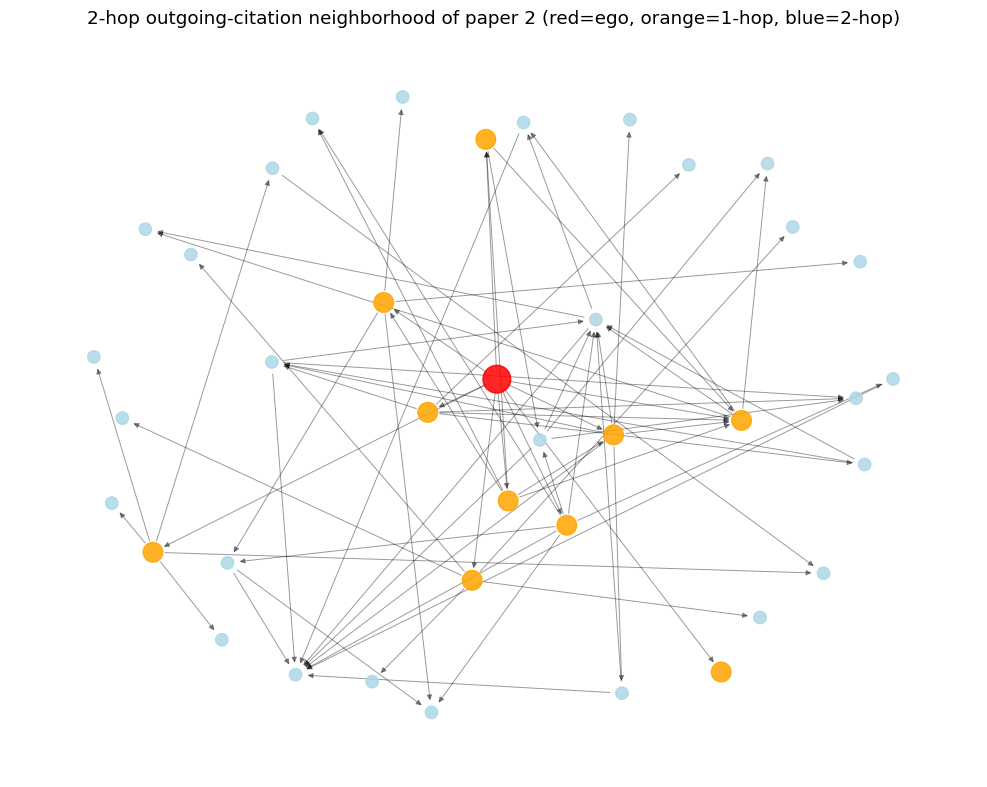

In [19]:
import networkx as nx
# Find a paper with ~15 outgoing citations
out_counts = out_deg.numpy()
candidates = np.where((out_counts >= 10) & (out_counts <= 20))[0]
ego = int(candidates[0])
print(f"Ego paper: {ego} (year={years[ego].item()}, out={out_deg[ego].item()}, in={in_deg[ego].item()})")

# Build adjacency for fast neighbor lookup (small subset)
out_adj = defaultdict(list)
for s, d in zip(cite_src.tolist(), cite_dst.tolist()):
    out_adj[s].append(d)
in_adj = defaultdict(list)
for s, d in zip(cite_src.tolist(), cite_dst.tolist()):
    in_adj[d].append(s)

# 2-hop neighborhood (out-direction)
hop1 = set(out_adj[ego])
hop2 = set()
for h in hop1:
    hop2.update(out_adj[h][:5])  # cap to avoid explosion
nodes = {ego} | hop1 | hop2
edges = []
for u in nodes:
    for v in out_adj[u]:
        if v in nodes:
            edges.append((u, v))

G_ego = nx.DiGraph()
G_ego.add_nodes_from(nodes)
G_ego.add_edges_from(edges)
print(f"Subgraph: {G_ego.number_of_nodes()} nodes, {G_ego.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G_ego, seed=42, k=1.5)
node_colors = ['red' if n == ego else ('orange' if n in hop1 else 'lightblue') for n in G_ego.nodes()]
node_sizes = [400 if n == ego else (200 if n in hop1 else 80) for n in G_ego.nodes()]
nx.draw_networkx_nodes(G_ego, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_ego, pos, alpha=0.4, arrows=True, arrowsize=8, width=0.7, ax=ax)
ax.set_title(f'2-hop outgoing-citation neighborhood of paper {ego} '
             f'(red=ego, orange=1-hop, blue=2-hop)')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_subgraph.png')
plt.show()

## Section 16 — Final summary table

Single consolidated table that the report's Dataset section can reproduce verbatim.

In [20]:
print("=" * 60)
print("OAG-CS DATASET SUMMARY (FOR REPORT)")
print("=" * 60)
print(f"\n{'Property':<45} {'Value':>15}")
print("-" * 60)
print(f"{'Papers':<45} {num_papers:>15,}")
print(f"{'Authors':<45} {num_authors:>15,}")
print(f"{'Citation edges (directed)':<45} {num_cites:>15,}")
print(f"{'Author-paper links':<45} {num_ap:>15,}")
print(f"{'Paper feature dim':<45} {embed_dim:>15}")
year_span = f"{years.min().item()}-{years.max().item()}"
print(f"{'Year span':<45} {year_span:>15}")
print()
print(f"{'Citation graph density':<45} {density:>15.2e}")
print(f"{'Avg out-degree':<45} {out_deg.float().mean():>15.2f}")
print(f"{'Avg in-degree':<45} {in_deg.float().mean():>15.2f}")
print(f"{'Average clustering coefficient (sampled)':<45} {avg_clust:>15.4f}")
print(f"{'Transitivity (global clustering, sampled)':<45} {transitivity:>15.4f}")
print()
print(f"{'Mean pairwise cosine sim (sample, raw X)':<45} {vals.mean():>15.4f}")
print()
single_str = f"{n_one:,} ({100*n_one/num_authors:.1f}%)"
multi_str = f"{n_multi:,} ({100*n_multi/num_authors:.1f}%)"
print(f"{'Authors with 1 paper (excluded)':<45} {single_str:>15}")
print(f"{'Authors with >=2 papers (eligible)':<45} {multi_str:>15}")
print()
l2_stats = next(s for s in level_stats if s['level'] == 2)
l2_cov_str = f"{l2_stats['paper_coverage']*100:.1f}%"
print(f"{'FoS L2 fields (used for hard negs)':<45} {l2_stats['n_fields']:>15,}")
print(f"{'L2 paper coverage':<45} {l2_cov_str:>15}")
print(f"{'L2 mean papers per field':<45} {l2_stats['mean_papers_per_field']:>15,.1f}")
print()
train_range = f"2005-{VAL_YEAR-1}"
print(f"{'Train year range':<45} {train_range:>15}")
print(f"{'Val year':<45} {VAL_YEAR:>15}")
print(f"{'Test year (>=)':<45} {TEST_YEAR:>15}")
print()
print(f"All figures saved to: {FIG_DIR.resolve()}")
print("\nGenerated figures:")
for f in sorted(FIG_DIR.glob('eda_*.png')):
    print(f"  {f.name}")

OAG-CS DATASET SUMMARY (FOR REPORT)

Property                                                Value
------------------------------------------------------------
Papers                                                546,704
Authors                                               511,122
Citation edges (directed)                           5,872,552
Author-paper links                                  1,552,196
Paper feature dim                                         768
Year span                                           1922-2020

Citation graph density                               1.96e-05
Avg out-degree                                          10.74
Avg in-degree                                           10.74
Average clustering coefficient (sampled)               0.1527
Transitivity (global clustering, sampled)              0.0559

Mean pairwise cosine sim (sample, raw X)               0.9908

Authors with 1 paper (excluded)               316,147 (61.9%)
Authors with >=2 papers (eligib